# RMS Prop (Root Mean Square Propagation)

​Rho​ is the cache memory decay rate. Because this optimizer, with default values, carries over so much momentum of gradient and the adaptive learning rate updates, even small gradient updates are enough to keep it going; therefore, a default learning rate of ​1​ is far too large and causes instant model instability. A learning rate that becomes stable again and gives fast enough updates is around ​0.001.

Where AdaGrad calculates the cache as: 
```python
cache += gradient ** 2 
```
RMSProp calculates the cache as: 
```python
cache = rho * cache + (​1- rho) * gradient ** 2 
```
Cache update:
$$
\underbrace{\text{cache}_t}_{\text{cache}} =
\underbrace{\rho \, \text{cache}_{t-1}}_{\text{keep part of old cache}}
+
\underbrace{(1-\rho)\, g_t^2}_{\text{new squared gradient part}}
$$

Gradient:
$$
\underbrace{g_t}_{\text{grad}} = \nabla_\theta J(\theta_t)
$$

Parameter update:
$$
\underbrace{\text{param\_update}}_{\text{param\_update}} =
-\underbrace{l_r}_{\text{learning\_rate}}
\frac{\underbrace{g_t}_{\text{grad}}}
{\underbrace{\sqrt{\text{cache}_t} + \epsilon}_{\text{normalization term}}}
$$

Parameter step:
$$
\underbrace{\theta_{t+1}}_{\text{new parameter}} =
\underbrace{\theta_t}_{\text{old parameter}}
+
\underbrace{\text{param\_update}}_{\text{update step}}
$$

# The Problem with AdaGrad

### Exponential Moving Average Expansion

Expanding the cache recursion shows how past gradients are weighted:

$$
\text{cache}_t =
(1-\rho) g_t^2

* \rho(1-\rho) g_{t-1}^2
* \rho^2(1-\rho) g_{t-2}^2
* \cdots
  $$

- Recent gradients have larger weights
- Older gradients decay exponentially by powers of ( \rho )

### With RMSProp

RMSProp can be viewed as modifying the learning rate per parameter:

$$
\underbrace{l_{r,\text{eff}}}_{\text{effective learning rate}} =
\frac{\underbrace{l_r}_{\text{base learning rate}}}
{\underbrace{\sqrt{\text{cache}_t} + \epsilon}_{\text{adaptive scaling}}}
$$

So the parameter update becomes:

$$
\theta_{t+1} =\theta_t - l_{r,\text{eff}} \cdot g_t
$$

* Large recent gradients -> larger cache -> smaller step
* Small or infrequent gradients -> smaller cache -> larger step


In [4]:
# imports
import matplotlib.pyplot as plt
import numpy as np 
import math
import nnfs

from nnfs.datasets import spiral_data

In [6]:
class Optimizer_RMSprop:
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho # new hyperparam

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))
    
    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            # initialize vectors with zeros of similar -
            # shapes since weights/biases are vectors
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)

        # RMS Prop
        layer.weight_cache = self.rho * layer.weight_cache + (1 - self.rho) * layer.dweights ** 2
        layer.bias_cache = self.rho * layer.bias_cache + (1 - self.rho) * layer.dbiases ** 2

        # Similar to AdaGrad
        layer.weights += -(self.current_learning_rate * layer.dweights) / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -(self.current_learning_rate * layer.dbiases) / (np.sqrt(layer.bias_cache) + self.epsilon)
    
    def post_update_params(self):
        self.iterations += 1

# Initialize Dense, ReLU, Loss

In [7]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

# Train

In [9]:
X, y_true = spiral_data(samples=100, classes=3)

learning_rate = 0.001
decay = 1e-4
epochs = 10_000

# re-initialize fresh weights
dense1_layer = Layer_Dense(2, 64)
relu_activation = Activation_ReLU()
output_layer = Layer_Dense(64, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
optimizer = Optimizer_RMSprop(learning_rate=learning_rate, decay=decay) # optimizer

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(epochs):
    # forward
    dense1_layer.forward(X)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss = loss_activation.forward(output_layer.output, y_true)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y_true.shape) == 2:
        y_labels = np.argmax(y_true, axis=1)
    else:
        y_labels = y_true
    accuracy = np.mean(predictions == y_labels)

    # backward
    loss_activation.backward(loss_activation.output, y_true)
    output_layer.backward(loss_activation.dinputs)
    relu_activation.backward(output_layer.dinputs)
    dense1_layer.backward(relu_activation.dinputs)

    # Update weights
    # stochastic gradient optimizer
    optimizer.pre_update_params() 
    optimizer.update_params(dense1_layer) 
    optimizer.update_params(output_layer) 
    optimizer.post_update_params()

    if epoch % (epochs // 10) == 0:
        print(f"epoch: {epoch:>4} accuracy: {accuracy:>4} loss: {loss:.4f}")
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)



epoch:    0 accuracy: 0.30666666666666664 loss: 1.1030
epoch: 1000 accuracy: 0.6466666666666666 loss: 0.9313
epoch: 2000 accuracy: 0.7233333333333334 loss: 0.7808
epoch: 3000 accuracy: 0.7466666666666667 loss: 0.6833
epoch: 4000 accuracy: 0.75 loss: 0.6209
epoch: 5000 accuracy: 0.7766666666666666 loss: 0.5717
epoch: 6000 accuracy: 0.7966666666666666 loss: 0.5278
epoch: 7000 accuracy: 0.8033333333333333 loss: 0.4875
epoch: 8000 accuracy: 0.82 loss: 0.4529
epoch: 9000 accuracy: 0.83 loss: 0.4228


# Visualize Evaluations

Final Values: Loss 0.39702331952798237 Accuracy 0.84 Learning Rate 0.0005000250012500625
Learning Rate 0.001 Decay 0.0001


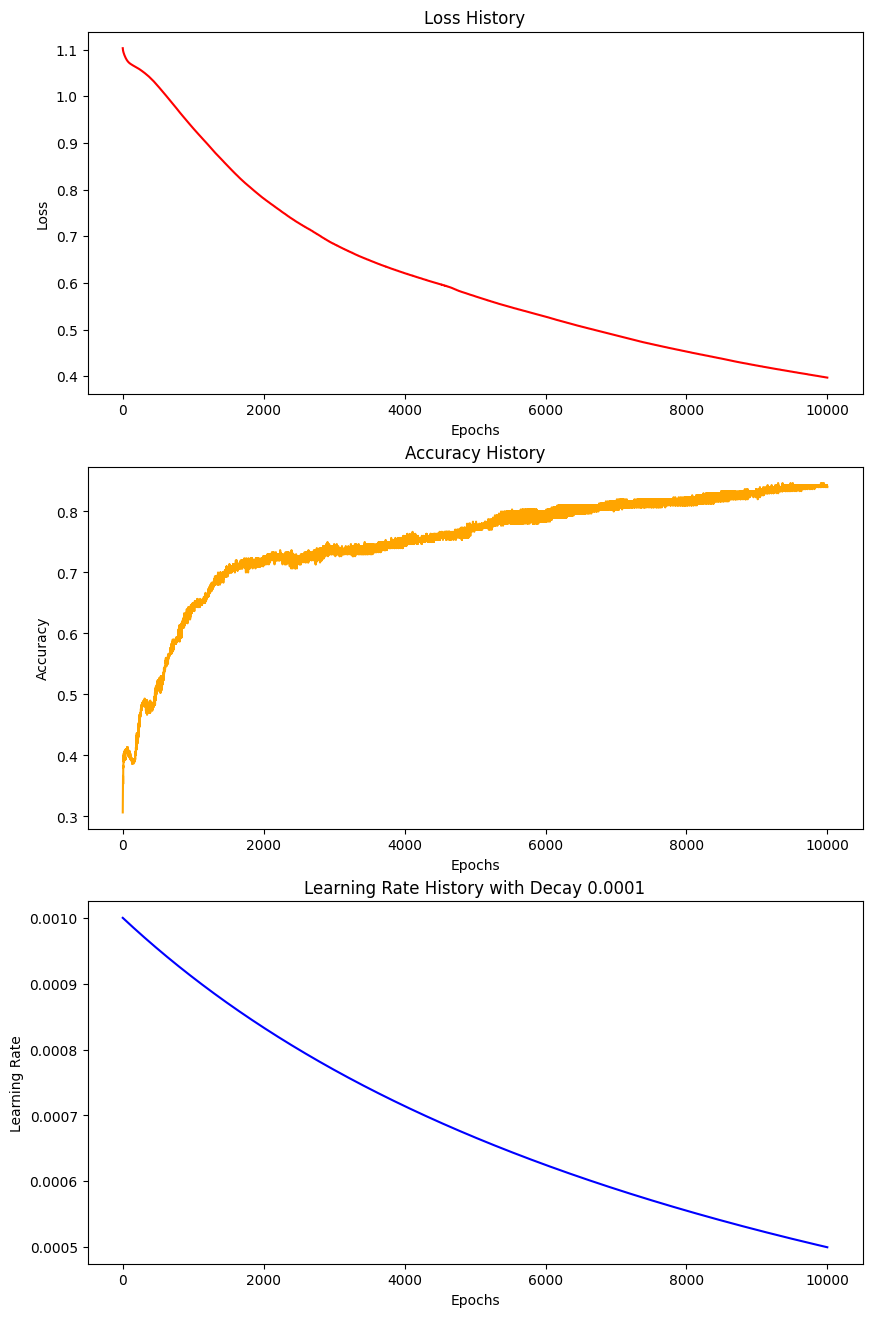

In [10]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")